<a href="https://colab.research.google.com/github/veronicaluzzi/Data-Science-Cohort-20/blob/main/Exercises/Module_4_Decision-tree/1a_Plotting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Plotting
For this exercise, you will do the following

1. Read in the data located on AWS at [company_sales_data.csv]( https://ddc-datascience.s3.amazonaws.com/company_sales_data.csv ).
1. Create at least two different plots of the data. Try to be creative and think about what information someone might want to know about this data set. You can use any plotting libary you would like. Below are some resources to help if needed.
      - https://matplotlib.org/stable/gallery/index.html
      - https://seaborn.pydata.org/examples/index.html
      - https://plotly.com/python/plotly-express/
1. Make sure you add axis labels and a legend (if necessary). Make sure your colors are easy to differentiate and that your font is large enough to easily read.

Hint: You may need to do some data restructuring/manipulation to create certain plots. The pandas `.melt()` and `.groupby()` methods may be helpful.

Reference: [Reshaping Tables With Pandas]( https://medium.com/towards-data-science/reshaping-data-with-pandas-ecff92572488 )

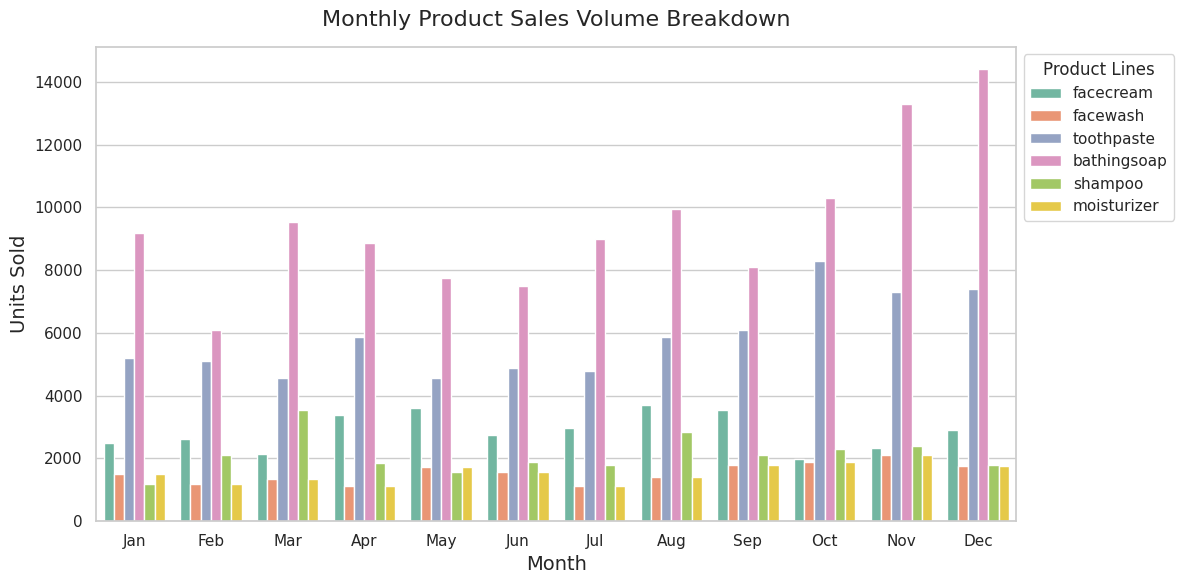

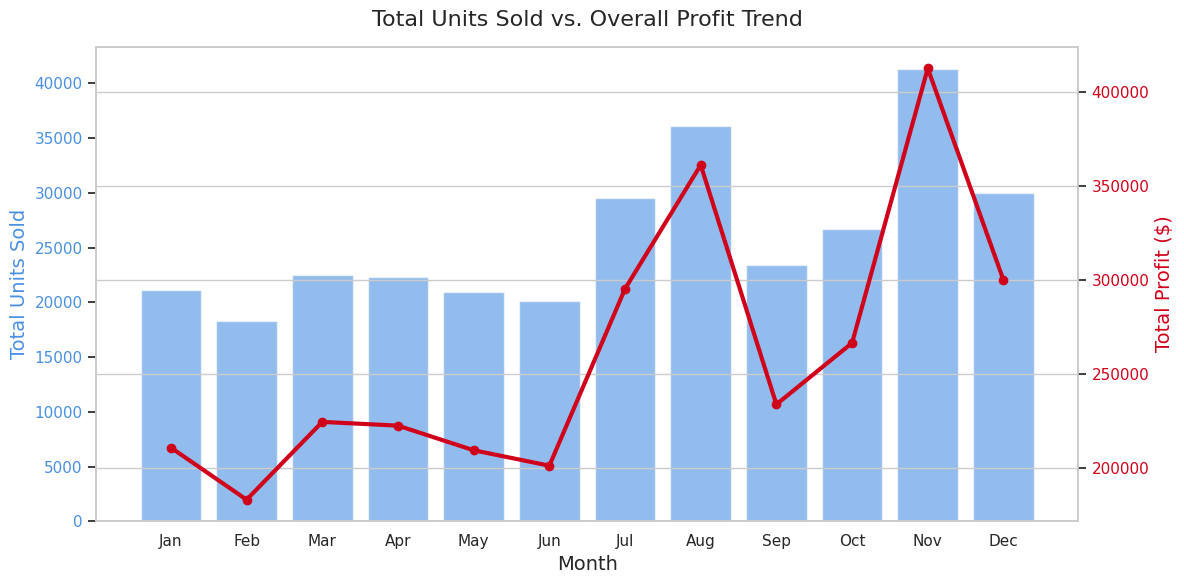

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Read in the data from the AWS URL
# (Replace the placeholder below with your specific AWS S3 bucket URL)
url = "https://ddc-datascience.s3.amazonaws.com/company_sales_data.csv"
df = pd.read_csv(url)

# Mapping month numbers to readable short names for clean X-axis labels
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df['month_name'] = df['month_number'].map(lambda x: month_names[x-1])

# Set a professional plotting style with larger baseline fonts
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'axes.labelsize': 14, 'axes.titlesize': 16})


# =====================================================================
# PLOT 1: Monthly Product Sales Breakdown (Using pandas.melt)
# Why: A manager would want to see which products dominate sales shares.
# =====================================================================

# List out the individual product columns
product_cols = ['facecream', 'facewash', 'toothpaste', 'bathingsoap', 'shampoo', 'moisturizer']

# Restructure wide column format into a clean long format for Seaborn
df_melted = pd.melt(
    df,
    id_vars=['month_name', 'month_number'],
    value_vars=product_cols,
    var_name='Product',
    value_name='Units Sold'
)

plt.figure(figsize=(12, 6))

# Creating a stacked-style bar chart using an explicit high-contrast color palette
sns.barplot(
    data=df_melted,
    x='month_name',
    y='Units Sold',
    hue='Product',
    palette='Set2'
)

plt.title('Monthly Product Sales Volume Breakdown', pad=15)
plt.xlabel('Month')
plt.ylabel('Units Sold')
plt.legend(title='Product Lines', loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()


# =====================================================================
# PLOT 2: Company Profit vs. Total Units Sold (Dual Axis Trend)
# Why: To observe if efficiency/profit margins hold up during peak volumes.
# =====================================================================

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plotting the Total Units Sold as a clear bar chart on the primary Y-axis
color_units = '#4A90E2' # Distinct clean blue
ax1.set_xlabel('Month')
ax1.set_ylabel('Total Units Sold', color=color_units)
bars = ax1.bar(df['month_name'], df['total_units'], color=color_units, alpha=0.6, label='Total Units')
ax1.tick_params(axis='y', labelcolor=color_units)
ax1.grid(False) # Turn off grid overlay to keep text highly legible

# Creating a secondary Y-axis sharing the same X-axis
ax2 = ax1.twinx()

# Overlaying Total Profit as a crisp line plot to stand out
color_profit = '#D0021B' # Distinct clean red
ax2.set_ylabel('Total Profit ($)', color=color_profit)
line = ax2.plot(df['month_name'], df['total_profit'], color=color_profit, linewidth=3, marker='o', label='Total Profit')
ax2.tick_params(axis='y', labelcolor=color_profit)

# Adding clear titles and structuring the visual
plt.title('Total Units Sold vs. Overall Profit Trend', pad=15)
fig.tight_layout()
plt.show()